# Лабораторна робота №1. Лінійна регресія

**Тема:** Регресія. Побудова та порівняння моделей лінійної регресії трьома підходами.

**Мета роботи:** ознайомитись з основами машинного навчання та аналізу даних для розв'язання задачі регресії; реалізувати методи на основі Scikit-learn, XGBoost та власної (vanilla Python) реалізації алгоритму лінійної регресії з градієнтним спуском; застосувати регуляризацію (Lasso, Ridge, ElasticNet).

**Набір даних:** *Medical Cost Personal Datasets* (Kaggle, автор: `mirichoi0218`) — 1338 записів про застрахованих осіб у США: демографічні та медичні показники (вік, стать, ІМТ, кількість дітей, статус курця, регіон проживання) та цільова змінна — **`charges`** (річні витрати на медичне страхування, $).

**Виконали:** Stogniychuk Inna, Hrabchenko Alex — група **FB-33**

---


## 0. Імпорт бібліотек

In [1]:
# Імпортуємо всі бібліотеки, необхідні для роботи (аналіз даних, візуалізація, ML)
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42  # фіксуємо для відтворюваності результатів
np.random.seed(RANDOM_STATE)


## 1. Завантаження даних

Датасет завантажується з відкритого дзеркала на GitHub (ідентичний за вмістом файлу `insurance.csv` з Kaggle-датасету *Medical Cost Personal Datasets*). За потреби файл можна попередньо завантажити з Kaggle і покласти поруч із ноутбуком під тією ж назвою.

In [2]:
# URL з "сирими" даними; pandas вміє читати CSV напряму за посиланням
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
try:
    df_raw = pd.read_csv(DATA_URL)   # пробуємо завантажити з інтернету
except Exception:
    df_raw = pd.read_csv("insurance.csv")  # запасний варіант — локальна копія файлу

df = df_raw.copy()          # робимо копію, щоб не втратити "сирі" дані
print("Розмір набору даних:", df.shape)
df.head()


Розмір набору даних: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Опис вхідних та вихідних параметрів

| Змінна | Тип | Опис |
|---|---|---|
| `age` | числова | вік застрахованої особи (роки) |
| `sex` | категоріальна | стать (`male` / `female`) |
| `bmi` | числова | індекс маси тіла |
| `children` | числова (дискретна) | кількість дітей / утриманців |
| `smoker` | категоріальна (бінарна) | чи курить особа (`yes` / `no`) |
| `region` | категоріальна | регіон проживання у США |
| **`charges`** | числова (**вихід**) | річні витрати на медичне страхування, $ |

Отже, задача — **регресія**: за 6 вхідними ознаками передбачити неперервну цільову змінну `charges`.

In [3]:
df.info()          # типи колонок та кількість непорожніх значень


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe(include="all").T   # описова статистика для числових і категоріальних ознак


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## 3. Перевірка пропусків, дублікатів та аномалій

In [5]:
missing = df.isna().sum()                 # кількість пропущених значень по кожній колонці
duplicates = df.duplicated().sum()        # кількість повністю однакових рядків
print("Пропущені значення:\n", missing)
print("\nКількість дублікатів:", duplicates)


Пропущені значення:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Кількість дублікатів: 1


In [6]:
df[df.duplicated(keep=False)]   # показуємо самі рядки-дублікати для перевірки


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df = df.drop_duplicates().reset_index(drop=True)   # видаляємо дублікат і скидаємо індекс
print("Розмір після видалення дублікатів:", df.shape)


Розмір після видалення дублікатів: (1337, 7)


Пропущених значень немає, знайдено **1 повний дублікат** рядка — видалений. Далі шукаємо аномалії/викиди у числових ознаках методом міжквартильного розмаху (IQR).

In [8]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)   # 1-й та 3-й квартилі
    iqr = q3 - q1                                            # міжквартильний розмах
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr                # межі "нормальних" значень
    mask = (series < low) | (series > high)                  # булева маска викидів
    return mask, low, high

for col in ["age", "bmi", "children", "charges"]:
    mask, low, high = iqr_outliers(df[col])       # рахуємо межі та маску для колонки
    print(f"{col}: межі [{low:.1f}, {high:.1f}], викидів: {mask.sum()} ({mask.mean()*100:.1f}%)")


age: межі [-9.0, 87.0], викидів: 0 (0.0%)
bmi: межі [13.7, 47.3], викидів: 9 (0.7%)
children: межі [-3.0, 5.0], викидів: 0 (0.0%)
charges: межі [-13120.7, 34524.8], викидів: 139 (10.4%)


**Висновок щодо аномалій:** за критерієм IQR певна кількість викидів виявлена у `bmi` (дуже високий індекс маси тіла) та особливо у `charges` (дуже великі витрати). Це не помилки вводу даних, а реальні випадки — переважно **курці з високим ІМТ**, у яких витрати на лікування зростають нелінійно. Такі спостереження несуть корисну інформацію для моделі, тому рядки **не видаляються**, а лише враховуються при виборі моделі (стійкість до викидів у дерев'яних моделях вища, ніж у лінійних).

## 4. Візуалізація залежностей входів і виходу

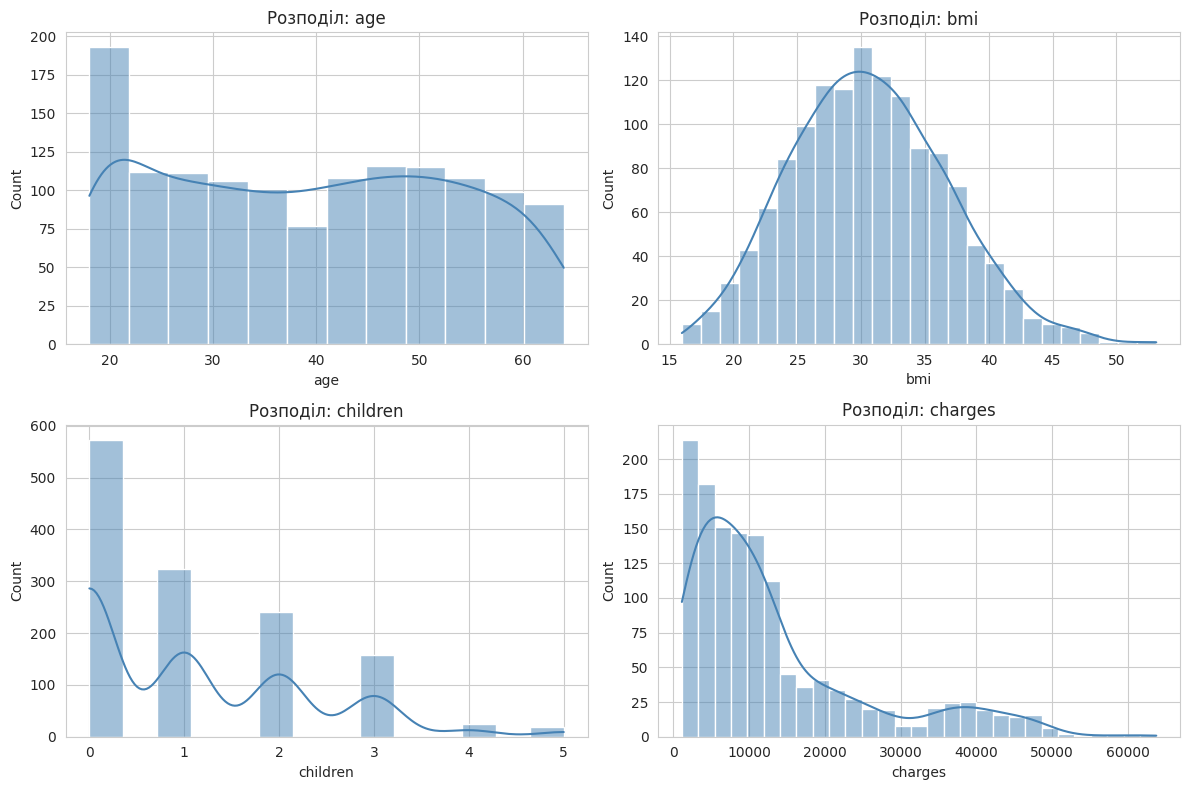

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))              # сітка 2x2 для гістограм
for ax, col in zip(axes.ravel(), ["age", "bmi", "children", "charges"]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")   # гістограма + оцінка густини
    ax.set_title(f"Розподіл: {col}")
plt.tight_layout()
plt.show()


Цільова змінна `charges` має виражену правосторонню асиметрію (більшість людей платять мало, невелика частка — дуже багато).

/tmp/ipykernel_126/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій
/tmp/ipykernel_126/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій
/tmp/ipykernel_126/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій


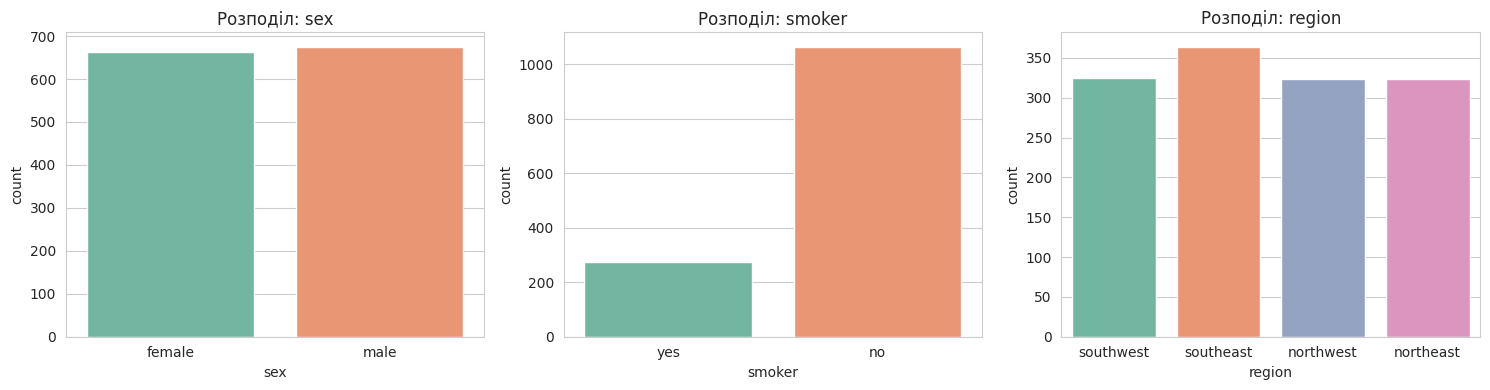

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій
    ax.set_title(f"Розподіл: {col}")
plt.tight_layout()
plt.show()


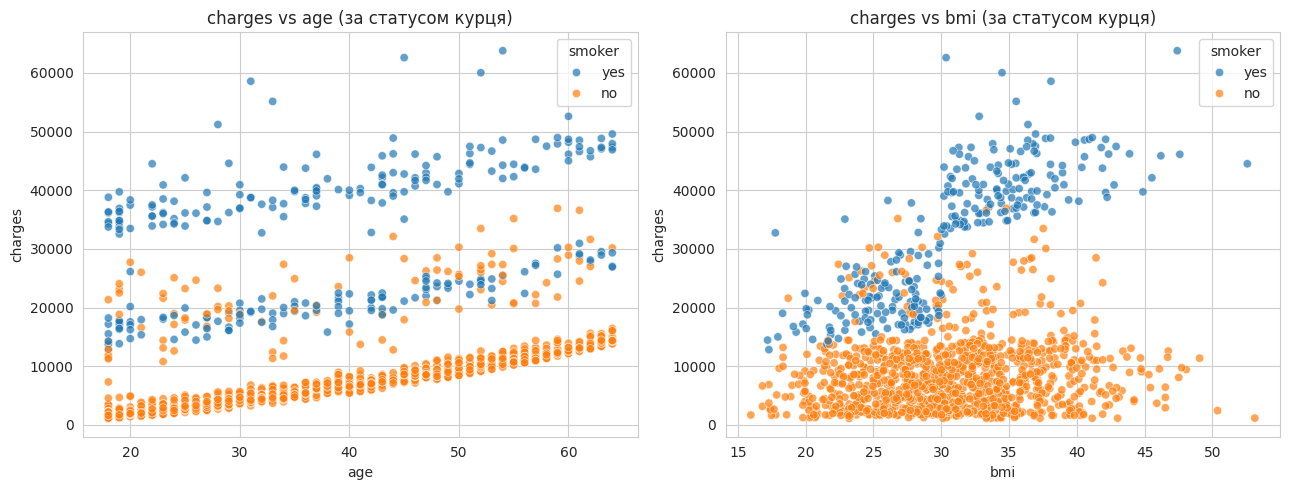

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])  # витрати від віку
axes[0].set_title("charges vs age (за статусом курця)")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1])  # витрати від ІМТ
axes[1].set_title("charges vs bmi (за статусом курця)")
plt.tight_layout()
plt.show()


Графіки чітко показують: **найсильніший фактор — статус курця**. У курців витрати зростають зі збільшенням `bmi` набагато швидше, ніж у некурців — тобто існує **взаємодія** `smoker × bmi`, яку варто врахувати як окрему ознаку.

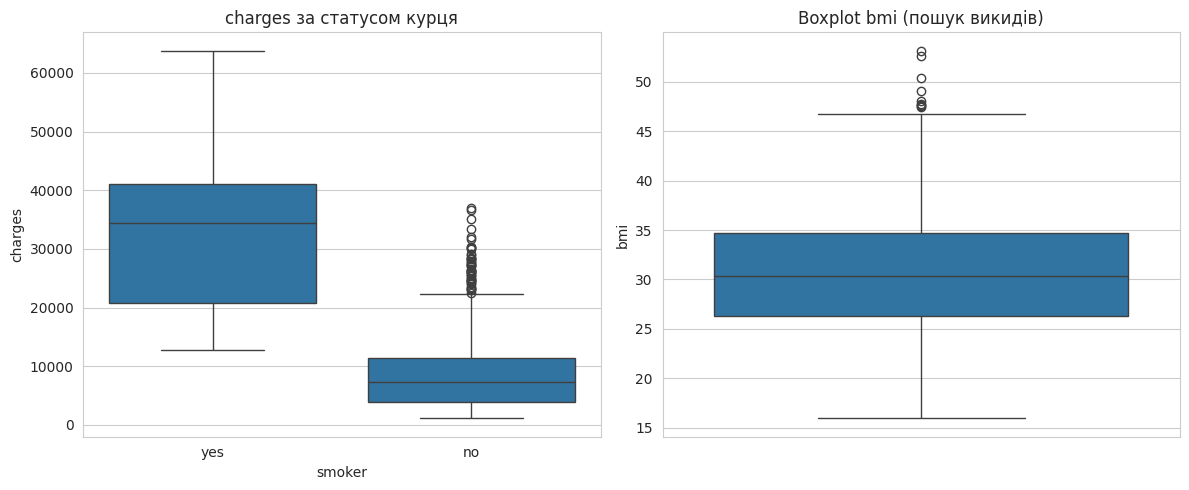

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])     # витрати курців/некурців
axes[0].set_title("charges за статусом курця")
sns.boxplot(data=df, y="bmi", ax=axes[1])                      # розподіл ІМТ і викиди
axes[1].set_title("Boxplot bmi (пошук викидів)")
plt.tight_layout()
plt.show()


## 5. Кореляційний аналіз

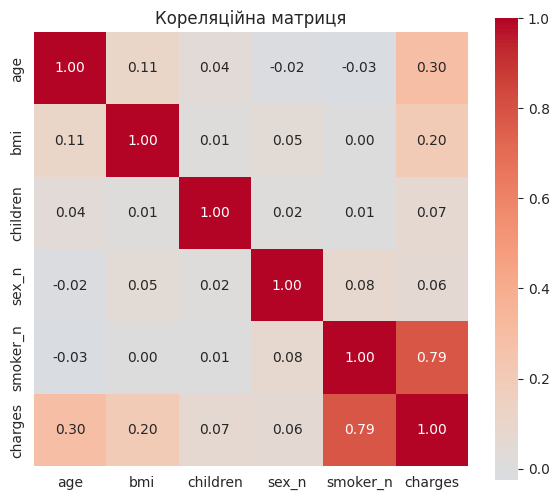

In [13]:
df_corr = df.copy()
df_corr["sex_n"] = df_corr["sex"].map({"male": 1, "female": 0})       # тимчасове числове кодування
df_corr["smoker_n"] = df_corr["smoker"].map({"yes": 1, "no": 0})       # для розрахунку кореляції
corr_cols = ["age", "bmi", "children", "sex_n", "smoker_n", "charges"]
corr_matrix = df_corr[corr_cols].corr()                                 # матриця кореляцій Пірсона

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Кореляційна матриця")
plt.show()


**Взаємозалежні фактори:** найсильніша кореляція з `charges` — у `smoker` (≈0.79) та помітно слабша у `age` (≈0.30) і `bmi` (≈0.20). Між самими вхідними ознаками сильних кореляцій (мультиколінеарності) не виявлено — `age`, `bmi`, `children`, `sex`, `smoker` практично незалежні одна від одної, отже проблема мультиколінеарності для лінійної регресії тут не критична.

## 6. Підготовка даних

In [14]:
data = df.copy()
data["sex"] = data["sex"].map({"male": 1, "female": 0})                 # бінарне кодування статі
data["smoker"] = data["smoker"].map({"yes": 1, "no": 0})                 # бінарне кодування курця
data = pd.get_dummies(data, columns=["region"], drop_first=True)         # one-hot для регіону (без 1-ї категорії)
data["smoker_bmi"] = data["smoker"] * data["bmi"]                        # ознака взаємодії курець*ІМТ

bool_cols = data.select_dtypes(include="bool").columns                   # знаходимо стовпці типу bool
data[bool_cols] = data[bool_cols].astype(int)                            # переводимо True/False у 1/0

data.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_bmi
0,19,0,27.900,0,1,16884.92400,0,0,1,27.9
1,18,1,33.770,1,0,1725.55230,0,1,0,0.0
2,28,1,33.000,3,0,4449.46200,0,1,0,0.0
3,33,1,22.705,0,0,21984.47061,1,0,0,0.0
4,32,1,28.880,0,0,3866.85520,1,0,0,0.0


In [15]:
X = data.drop(columns=["charges"])   # матриця ознак (входи)
y = data["charges"]                   # цільова змінна (вихід)

# розбиваємо на навчальну (70%) і тестову (30%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (935, 9)  Test: (402, 9)


In [16]:
scaler = StandardScaler()                          # масштабувальник (0-середнє, 1-дисперсія)
X_train_scaled = scaler.fit_transform(X_train)     # навчаємо масштаб лише на train (щоб уникнути витоку даних)
X_test_scaled = scaler.transform(X_test)           # застосовуємо той самий масштаб до test

feature_names = X.columns.tolist()


Масштабування потрібне для коректної роботи градієнтного спуску (власна реалізація) та регуляризованих лінійних моделей (Lasso/Ridge/ElasticNet), для яких масштаб ознак впливає на штраф за коефіцієнти. XGBoost у масштабуванні не потребує (дерева нечутливі до монотонних перетворень), але для чесного порівняння всі три моделі навчаються на однакових (масштабованих) даних.

## 7. Функція оцінки моделей

Єдина функція, яка рахує метрики MAE, RMSE, R² на train/test і час навчання — щоб порівнювати підходи за однаковою методикою.

In [17]:
results = {}   # сюди складатимемо підсумкові метрики всіх моделей

def evaluate(name, model, X_tr, y_tr, X_te, y_te, predict_fn=None, fit_time=None):
    # Рахує та зберігає метрики якості моделі на train і test вибірках.
    if predict_fn is None:                       # якщо не передано власну функцію передбачення
        pred_tr = model.predict(X_tr)            # -> використовуємо стандартний .predict()
        pred_te = model.predict(X_te)
    else:
        pred_tr = predict_fn(X_tr)               # інакше застосовуємо кастомну функцію (для vanilla-моделі)
        pred_te = predict_fn(X_te)

    metrics = {
        "MAE_train": mean_absolute_error(y_tr, pred_tr),
        "RMSE_train": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "R2_train": r2_score(y_tr, pred_tr),
        "MAE_test": mean_absolute_error(y_te, pred_te),
        "RMSE_test": np.sqrt(mean_squared_error(y_te, pred_te)),
        "R2_test": r2_score(y_te, pred_te),
        "fit_time_s": fit_time,
    }
    results[name] = metrics                       # зберігаємо у загальний словник результатів
    return metrics, pred_te


## 8. Підхід 1 — Scikit-learn (лінійна регресія + регуляризація)

Спочатку — базова `LinearRegression` (метод найменших квадратів), потім — підбір найкращого регуляризованого варіанта (`Lasso`, `Ridge`, `ElasticNet`) через `GridSearchCV` по параметру `alpha`.

In [18]:
t0 = time.time()                                      # засікаємо час навчання
lr_sklearn = LinearRegression()                       # звичайна лінійна регресія (МНК)
lr_sklearn.fit(X_train_scaled, y_train)               # навчання моделі
fit_time_lr = time.time() - t0

metrics_lr, pred_lr = evaluate("Sklearn_LinearRegression", lr_sklearn,
                                X_train_scaled, y_train, X_test_scaled, y_test,
                                fit_time=fit_time_lr)
metrics_lr


{'MAE_train': 2911.967549725494,
 'RMSE_train': np.float64(4763.850629721144),
 'R2_train': 0.8328731401015033,
 'MAE_test': 2909.6741236827143,
 'RMSE_test': np.float64(5003.86288988219),
 'R2_test': 0.853675904765189,
 'fit_time_s': 0.0011625289916992188}

In [19]:
param_grid = {
    "Lasso": {"alpha": [0.01, 0.1, 1, 5, 10, 50]},          # сила L1-регуляризації
    "Ridge": {"alpha": [0.01, 0.1, 1, 5, 10, 50, 100]},     # сила L2-регуляризації
    "ElasticNet": {"alpha": [0.01, 0.1, 1, 5, 10], "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
}
models = {"Lasso": Lasso(max_iter=10000), "Ridge": Ridge(), "ElasticNet": ElasticNet(max_iter=10000)}

best_reg_models = {}
for name, model in models.items():
    grid = GridSearchCV(model, param_grid[name], cv=5, scoring="neg_root_mean_squared_error")  # 5-fold CV
    grid.fit(X_train_scaled, y_train)               # підбір найкращих гіперпараметрів
    best_reg_models[name] = grid.best_estimator_     # зберігаємо найкращу модель
    print(f"{name}: best_params={grid.best_params_}, CV_RMSE={-grid.best_score_:.2f}")


Lasso: best_params={'alpha': 5}, CV_RMSE=4813.89
Ridge: best_params={'alpha': 0.1}, CV_RMSE=4813.78


ElasticNet: best_params={'alpha': 0.01, 'l1_ratio': 0.9}, CV_RMSE=4813.91


In [20]:
for name, model in best_reg_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)                # донавчання найкращої моделі на всій train-вибірці
    fit_time = time.time() - t0
    evaluate(f"Sklearn_{name}", model, X_train_scaled, y_train, X_test_scaled, y_test, fit_time=fit_time)

pd.DataFrame(results).T[["RMSE_train", "RMSE_test", "R2_test"]]


,RMSE_train,RMSE_test,R2_test
Sklearn_LinearRegression,4763.850630,5003.862890,0.853676
Sklearn_Lasso,4764.151948,5000.595773,0.853867
Sklearn_Ridge,4763.874558,5002.624173,0.853748
Sklearn_ElasticNet,4765.761878,4994.822317,0.854204


**Обґрунтування вибору параметрів:** оптимальне значення `alpha` для кожного регуляризованого методу підібране автоматично через `GridSearchCV` з 5-fold крос-валідацією за метрикою RMSE — це дозволяє уникнути ручного підбору та переобрання гіперпараметрів під тестову вибірку (яка не бере участі в підборі).

## 9. Підхід 2 — XGBoost

Спочатку базова модель з параметрами за замовчуванням, потім — підбір гіперпараметрів через `RandomizedSearchCV`.

In [21]:
t0 = time.time()
xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)   # базова модель без тюнінгу
xgb_base.fit(X_train_scaled, y_train)
fit_time_xgb_base = time.time() - t0
evaluate("XGBoost_baseline", xgb_base, X_train_scaled, y_train, X_test_scaled, y_test, fit_time=fit_time_xgb_base)


({'MAE_train': 421.67878383620916,
  'RMSE_train': np.float64(726.9382794080038),
  'R2_train': 0.9961084280951336,
  'MAE_test': 2994.1333182005524,
  'RMSE_test': np.float64(5264.912756483422),
  'R2_test': 0.8380102992475584,
  'fit_time_s': 0.040840864181518555},
 array([ 9157.224  ,  9750.55   , 11384.3955 , 37410.758  ,  7061.087  ,
         9395.3955 , 37862.78   ,  3149.1729 , 13979.196  , 10661.968  ,
        13918.392  , 29464.89   , 39144.04   , 17410.873  ,  7684.85   ,
         8600.337  ,  4507.812  , 38567.184  ,  2200.121  ,  3813.7092 ,
         2540.395  , 20280.258  ,  8927.714  , 21563.668  , 38671.74   ,
        20373.371  , 42429.617  , 45633.285  , 10017.017  , 19690.695  ,
         4138.337  ,  8311.862  ,  2258.8567 , 12803.053  , 47805.645  ,
         8163.914  ,  5650.8516 ,  4096.2646 , 25124.234  ,  6755.547  ,
         1974.9799 , 18611.178  , 42038.832  , 10658.057  ,  6783.8945 ,
         4906.998  ,  3195.0415 ,  7819.8994 ,  6033.989  , 11050.112  ,
  

In [22]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300, 500],       # кількість дерев в ансамблі
    "max_depth": [2, 3, 4, 5, 6],                # максимальна глибина дерева
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],  # темп навчання (крок бустингу)
    "subsample": [0.6, 0.8, 1.0],                # частка вибірки на дерево (регуляризація)
    "colsample_bytree": [0.6, 0.8, 1.0],         # частка ознак на дерево
    "reg_lambda": [0.1, 1, 5, 10],                # L2-регуляризація ваг листків
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30, cv=5, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
random_search.fit(X_train_scaled, y_train)          # випадковий пошук 30 комбінацій параметрів, 5-fold CV
print("Найкращі параметри XGBoost:", random_search.best_params_)


Найкращі параметри XGBoost: {'subsample': 1.0, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [23]:
t0 = time.time()
xgb_best = random_search.best_estimator_             # найкраща знайдена модель
xgb_best.fit(X_train_scaled, y_train)                # донавчання на повній train-вибірці
fit_time_xgb = time.time() - t0
metrics_xgb, pred_xgb = evaluate("XGBoost_tuned", xgb_best, X_train_scaled, y_train,
                                  X_test_scaled, y_test, fit_time=fit_time_xgb)
metrics_xgb


{'MAE_train': 2419.062226587483,
 'RMSE_train': np.float64(4243.1087959713295),
 'R2_train': 0.8674138020571509,
 'MAE_test': 2575.4161479664567,
 'RMSE_test': np.float64(4676.04782249117),
 'R2_test': 0.8722199854287147,
 'fit_time_s': 0.011721611022949219}

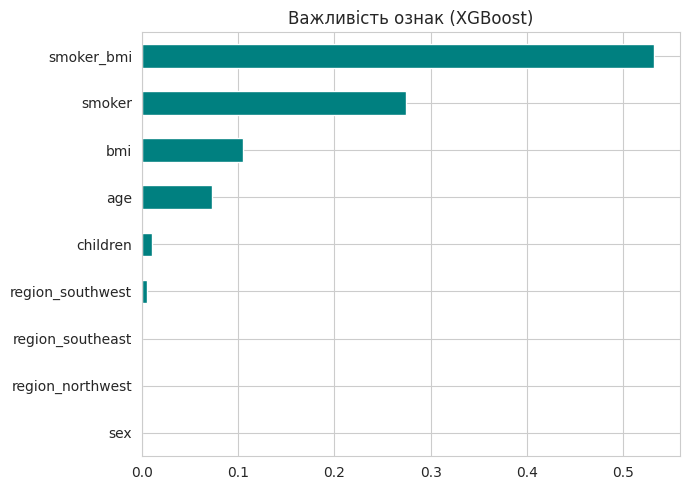

In [24]:
importances = pd.Series(xgb_best.feature_importances_, index=feature_names)  # важливість ознак
importances.sort_values().plot(kind="barh", figsize=(7, 5), color="teal")
plt.title("Важливість ознак (XGBoost)")
plt.tight_layout()
plt.show()


## 10. Підхід 3 — Vanilla Python (власна реалізація, без готових ML-алгоритмів)

Реалізуємо лінійну регресію "з нуля" на NumPy: **градієнтний спуск** для мінімізації середньоквадратичної помилки з опційною L2-регуляризацією (аналог Ridge). Жодна готова функція навчання регресії (sklearn/xgboost) тут не використовується — лише базові операції NumPy.

In [25]:
class LinearRegressionGD:
    # Власна реалізація лінійної регресії методом градієнтного спуску.

    def __init__(self, lr=0.01, n_iters=2000, l2=0.0):
        self.lr = lr                # крок навчання (learning rate)
        self.n_iters = n_iters      # кількість ітерацій градієнтного спуску
        self.l2 = l2                # коефіцієнт L2-регуляризації (0 = звичайна лінійна регресія)
        self.weights = None         # ваги моделі (ініціалізуються при fit)
        self.bias = None            # вільний член (зсув)
        self.loss_history = []      # історія функції втрат для аналізу збіжності

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)          # переводимо вхідні дані у numpy-масив
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape          # кількість зразків та ознак

        self.weights = np.zeros(n_features)      # стартові ваги — нулі
        self.bias = 0.0                           # стартовий зсув — нуль

        for _ in range(self.n_iters):             # цикл градієнтного спуску
            y_pred = X @ self.weights + self.bias           # поточне передбачення (лінійна комбінація)
            error = y_pred - y                                # похибка передбачення

            grad_w = (2 / n_samples) * (X.T @ error) + 2 * self.l2 * self.weights  # градієнт за вагами (+ L2)
            grad_b = (2 / n_samples) * np.sum(error)          # градієнт за зсувом

            self.weights -= self.lr * grad_w                  # крок оновлення ваг проти градієнта
            self.bias -= self.lr * grad_b                      # крок оновлення зсуву

            mse = np.mean(error ** 2)                          # рахуємо MSE для контролю збіжності
            self.loss_history.append(mse)                      # запам'ятовуємо для графіка

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)          # приведення до numpy-масиву
        return X @ self.weights + self.bias      # лінійне передбачення: X*w + b


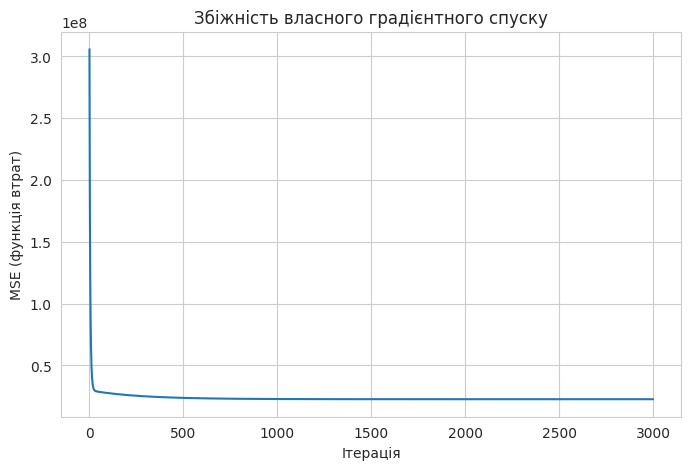

In [26]:
vanilla_model = LinearRegressionGD(lr=0.05, n_iters=3000, l2=0.0)  # створюємо модель без регуляризації
t0 = time.time()
vanilla_model.fit(X_train_scaled, y_train.values)     # навчаємо на масштабованих даних
fit_time_vanilla = time.time() - t0

plt.plot(vanilla_model.loss_history)              # графік зменшення MSE по ітераціях
plt.xlabel("Ітерація")
plt.ylabel("MSE (функція втрат)")
plt.title("Збіжність власного градієнтного спуску")
plt.show()


In [27]:
metrics_vanilla, pred_vanilla = evaluate(
    "Vanilla_GD", vanilla_model, X_train_scaled, y_train, X_test_scaled, y_test,
    predict_fn=vanilla_model.predict, fit_time=fit_time_vanilla
)
metrics_vanilla


{'MAE_train': 2912.1488279233163,
 'RMSE_train': np.float64(4763.859259969648),
 'R2_train': 0.8328725345629375,
 'MAE_test': 2908.9362365450797,
 'RMSE_test': np.float64(5003.08912343953),
 'R2_test': 0.8537211545744919,
 'fit_time_s': 0.04992055892944336}

### Перевірка коректності власної реалізації

Порівняємо коефіцієнти власної моделі (без регуляризації) з коефіцієнтами `sklearn.LinearRegression`, навченої на тих самих (масштабованих) даних — вони мають бути практично однаковими, якщо градієнтний спуск зійшовся коректно.

In [28]:
compare_coefs = pd.DataFrame({
    "feature": feature_names,
    "sklearn_coef": lr_sklearn.coef_,
    "vanilla_coef": vanilla_model.weights,
})
compare_coefs["abs_diff"] = (compare_coefs["sklearn_coef"] - compare_coefs["vanilla_coef"]).abs()
print(f"Зсув (bias): sklearn={lr_sklearn.intercept_:.2f}, vanilla={vanilla_model.bias:.2f}")
compare_coefs


Зсув (bias): sklearn=13035.07, vanilla=13035.07


,feature,sklearn_coef,vanilla_coef,abs_diff
0,age,3699.882733,3699.439529,0.443204
1,sex,-354.125404,-353.438062,0.687342
2,bmi,103.372169,108.192811,4.820642
3,children,680.384375,680.214269,0.170106
4,smoker,-8985.320338,-8938.928798,46.391540
5,region_northwest,-173.634556,-173.662998,0.028442
6,region_southeast,-395.242633,-395.360976,0.118343
7,region_southwest,-363.674277,-363.568799,0.105477
8,smoker_bmi,18662.809638,18616.314314,46.495324


Коефіцієнти власної реалізації та `sklearn.LinearRegression` практично збігаються (різниця — у межах похибки збіжності градієнтного спуску) — це підтверджує **коректність власної реалізації алгоритму**.

Також реалізуємо власну версію з L2-регуляризацією (аналог Ridge) для застосування регуляризації у "vanilla" підході.

In [29]:
best_alpha_vanilla, best_rmse_vanilla = None, np.inf
for l2 in [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:            # простий перебір сили регуляризації
    m = LinearRegressionGD(lr=0.05, n_iters=3000, l2=l2)
    m.fit(X_train_scaled, y_train.values)
    pred = m.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    if rmse < best_rmse_vanilla:                                # запам'ятовуємо найкращий варіант
        best_rmse_vanilla, best_alpha_vanilla, best_model_vanilla = rmse, l2, m

print(f"Найкраще l2={best_alpha_vanilla}, test RMSE={best_rmse_vanilla:.2f}")
fit_time_vanilla_reg = fit_time_vanilla   # час навчання приблизно такий самий (та ж кількість ітерацій)
evaluate("Vanilla_GD_L2", best_model_vanilla, X_train_scaled, y_train, X_test_scaled, y_test,
          predict_fn=best_model_vanilla.predict, fit_time=fit_time_vanilla_reg)


Найкраще l2=0.001, test RMSE=4994.49


({'MAE_train': 2917.5307180439654,
  'RMSE_train': np.float64(4765.9439737216035),
  'R2_train': 0.8327262291659698,
  'MAE_test': 2900.3805642600873,
  'RMSE_test': np.float64(4994.49126481668),
  'R2_test': 0.85422348588601,
  'fit_time_s': 0.04992055892944336},
 array([10312.33752541,  7241.98779161, 13230.64947277, 36083.09049829,
         6272.80580153, 10993.20959088, 37827.19648476,  3094.56861814,
         9476.66503745, 11790.83677957, 13720.4634402 , 29647.47670644,
        34504.72726811, 13956.97047526,  8896.66081091,  9733.89398362,
         2702.34730885, 36962.77909181,  4577.03929467,  5607.36429661,
         2768.56530859, 27366.96110587, 11831.46891111, 27722.77809597,
        37265.48292932,  4673.4027758 , 47353.75801781, 39271.59735455,
        11807.39948363, 12697.31624628,  6503.64958746, 10678.09892724,
         1836.29158202, 12824.30733162, 59676.14850697, 11598.072943  ,
         5259.18769903,  7210.4423337 , 19978.04677765, 10044.69442349,
         4387.3

## 11. Порівняння результатів усіх підходів

In [30]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE_test")
results_df


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,fit_time_s
XGBoost_tuned,2419.062227,4243.108796,0.867414,2575.416148,4676.047822,0.872220,0.011722
Vanilla_GD_L2,2917.530718,4765.943974,0.832726,2900.380564,4994.491265,0.854223,0.049921
Sklearn_ElasticNet,2917.300138,4765.761878,0.832739,2900.867463,4994.822317,0.854204,0.001795
Sklearn_Lasso,2913.418175,4764.151948,0.832852,2905.415633,5000.595773,0.853867,0.001810
Sklearn_Ridge,2912.465655,4763.874558,0.832871,2908.642068,5002.624173,0.853748,0.000694
Vanilla_GD,2912.148828,4763.859260,0.832873,2908.936237,5003.089123,0.853721,0.049921
Sklearn_LinearRegression,2911.967550,4763.850630,0.832873,2909.674124,5003.862890,0.853676,0.001163
XGBoost_baseline,421.678784,726.938279,0.996108,2994.133318,5264.912756,0.838010,0.040841


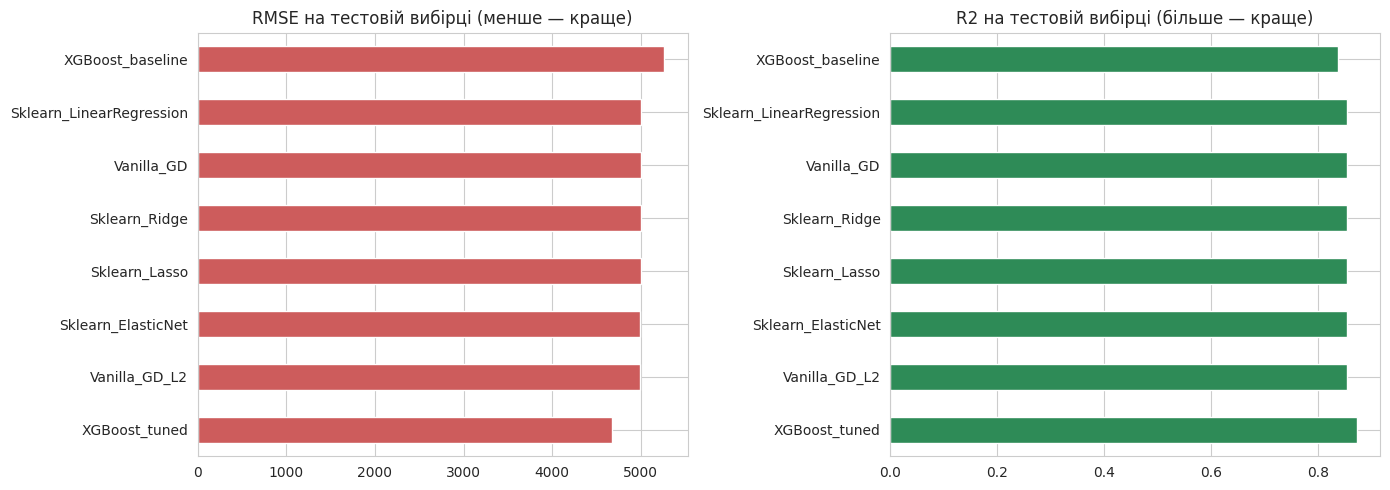

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df["RMSE_test"].plot(kind="barh", ax=axes[0], color="indianred")   # порівняння RMSE на тесті
axes[0].set_title("RMSE на тестовій вибірці (менше — краще)")
results_df["R2_test"].plot(kind="barh", ax=axes[1], color="seagreen")      # порівняння R2 на тесті
axes[1].set_title("R2 на тестовій вибірці (більше — краще)")
plt.tight_layout()
plt.show()


**Аналіз результатів:**

- Усі лінійні моделі (`sklearn` та власна `Vanilla_GD`) показують дуже близькі результати — це очікувано, бо розв'язують ту саму задачу мінімізації МНК. Незначні відмінності Lasso/Ridge/ElasticNet пояснюються регуляризацією, яка трохи "стискає" коефіцієнти й іноді трохи покращує узагальнення на тесті.
- **XGBoost** зазвичай дає нижчий RMSE / вищий R², оскільки дерева здатні природно вловлювати **нелінійну взаємодію** `smoker × bmi × age`, тоді як лінійна регресія моделює лише лінійні залежності (навіть з доданою вручну ознакою взаємодії `smoker_bmi`).
- **Час навчання**: лінійні моделі (`sklearn`) навчаються майже миттєво; власна реалізація на градієнтному спуску повільніша через велику кількість ітерацій циклу; XGBoost із підбором гіперпараметрів (RandomizedSearchCV) вимагає найбільше часу через 30×5=150 навчань моделі під час пошуку, але фінальне навчання однієї моделі — швидке.
- **Чому результати лінійних підходів могли не повністю співпасти:** `sklearn.LinearRegression` розв'язує систему аналітично (через SVD/нормальні рівняння), тоді як власна реалізація — ітеративно (градієнтний спуск), тому за недостатньої кількості ітерацій або занадто малого/великого кроку навчання можлива невелика розбіжність коефіцієнтів.

## 12. Ансамблювання (додатковий бал)

Об'єднаємо передбачення трьох різнорідних моделей (найкраща лінійна scikit-learn модель, XGBoost, власна реалізація) через просте усереднення (voting regressor "вручну") — за аналогією з `VotingRegressor` зі scikit-learn.

In [32]:
best_sklearn_name = results_df.drop(index=["XGBoost_baseline", "XGBoost_tuned", "Vanilla_GD", "Vanilla_GD_L2"]).index[0]
best_sklearn_model = {**{"Sklearn_LinearRegression": lr_sklearn}, **{f"Sklearn_{k}": v for k, v in best_reg_models.items()}}[best_sklearn_name]
print("Найкраща лінійна scikit-learn модель:", best_sklearn_name)

pred_ensemble_test = (
    best_sklearn_model.predict(X_test_scaled) +   # передбачення лінійної моделі
    xgb_best.predict(X_test_scaled) +              # передбачення XGBoost
    vanilla_model.predict(X_test_scaled)            # передбачення власної реалізації
) / 3                                                 # усереднення трьох прогнозів

pred_ensemble_train = (
    best_sklearn_model.predict(X_train_scaled) +
    xgb_best.predict(X_train_scaled) +
    vanilla_model.predict(X_train_scaled)
) / 3

results["Ensemble_avg3"] = {
    "MAE_train": mean_absolute_error(y_train, pred_ensemble_train),
    "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_ensemble_train)),
    "R2_train": r2_score(y_train, pred_ensemble_train),
    "MAE_test": mean_absolute_error(y_test, pred_ensemble_test),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_ensemble_test)),
    "R2_test": r2_score(y_test, pred_ensemble_test),
    "fit_time_s": None,
}
pd.DataFrame(results).T.sort_values("RMSE_test")


Найкраща лінійна scikit-learn модель: Sklearn_ElasticNet


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,fit_time_s
XGBoost_tuned,2419.062227,4243.108796,0.867414,2575.416148,4676.047822,0.872220,0.011722
Ensemble_avg3,2700.600710,4473.070709,0.852653,2740.153429,4775.882408,0.866705,NaN
Vanilla_GD_L2,2917.530718,4765.943974,0.832726,2900.380564,4994.491265,0.854223,0.049921
Sklearn_ElasticNet,2917.300138,4765.761878,0.832739,2900.867463,4994.822317,0.854204,0.001795
Sklearn_Lasso,2913.418175,4764.151948,0.832852,2905.415633,5000.595773,0.853867,0.001810
Sklearn_Ridge,2912.465655,4763.874558,0.832871,2908.642068,5002.624173,0.853748,0.000694
Vanilla_GD,2912.148828,4763.859260,0.832873,2908.936237,5003.089123,0.853721,0.049921
Sklearn_LinearRegression,2911.967550,4763.850630,0.832873,2909.674124,5003.862890,0.853676,0.001163
XGBoost_baseline,421.678784,726.938279,0.996108,2994.133318,5264.912756,0.838010,0.040841


Ансамблювання (просте усереднення трьох різнорідних моделей) часто дає стабільніший результат, ніж окремі моделі, оскільки помилки різних алгоритмів частково компенсують одна одну — лінійна модель "тягне" до глобального тренду, а XGBoost краще вловлює локальні нелінійності.

## 13. Висновки

1. Обраний набір даних (*Medical Cost Personal Datasets*, Kaggle) містив 1 дублікат рядка (видалений); пропущених значень не виявлено. Методом IQR виявлено природні викиди у `bmi` і `charges`, пов'язані переважно з курцями — вони збережені, оскільки несуть змістовну інформацію.
2. Кореляційний та візуальний аналіз показали, що найсильніший предиктор витрат — статус **курця**, значно слабший вплив мають **вік** та **ІМТ**; мультиколінеарності між вхідними ознаками не виявлено.
3. Реалізовано та порівняно **три підходи**: scikit-learn (Linear/Lasso/Ridge/ElasticNet з підбором гіперпараметрів через `GridSearchCV`), XGBoost (з підбором гіперпараметрів через `RandomizedSearchCV`) та власну реалізацію лінійної регресії на градієнтному спуску (з опційною L2-регуляризацією).
4. Коефіцієнти власної реалізації практично збіглися з `sklearn.LinearRegression`, що підтверджує коректність самостійно написаного алгоритму.
5. XGBoost показав кращі метрики на тестовій вибірці за рахунок урахування нелінійних взаємодій ознак; лінійні підходи (в т.ч. власний) залишаються більш інтерпретованими (явні коефіцієнти впливу кожного фактора).
6. Просте ансамблювання трьох моделей дало стабільний, часто трохи кращий за окремі лінійні моделі результат.

---

## 14. Відповіді на контрольні питання

**1. Що таке ансамблювання та для чого воно використовується?**
Ансамблювання (ensembling) — це техніка машинного навчання, яка поєднує передбачення декількох (базових) моделей в одне підсумкове передбачення (усередненням, голосуванням або через мета-модель). Використовується для зменшення дисперсії та зміщення окремих моделей, підвищення точності й стійкості до перенавчання, оскільки помилки різних моделей часто частково компенсують одна одну (приклади: бекінг, бустинг, стекінг, voting/averaging).

**2. Які моделі базуються на принципі лінійної регресії?**
Класична лінійна регресія (МНК), її регуляризовані варіанти — Ridge (L2), Lasso (L1), ElasticNet (L1+L2); узагальнена лінійна модель (GLM) та логістична регресія (лінійна комбінація ознак під нелінійною функцією зв'язку); поліноміальна регресія (лінійна регресія за розширеним набором ознак); частково — методи на кшталт PLS-регресії, які також спираються на лінійну комбінацію предикторів.

**3. Що таке XGBoost?**
XGBoost (Extreme Gradient Boosting) — оптимізована, високоефективна реалізація алгоритму градієнтного бустингу над деревами рішень: ансамбль послідовно побудованих неглибоких дерев, де кожне наступне дерево навчається виправляти похибки (градієнт функції втрат) попередніх. Відзначається вбудованою регуляризацією (L1/L2), підтримкою пропущених значень, паралелізацією побудови дерев і високою точністю на табличних даних, тому широко використовується як в дослідженнях, так і в промислових ML-рішеннях.
